<a href="https://colab.research.google.com/github/vberezina/machine-learning-basics/blob/main/practices/LR5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ЛАБОРАТОРНАЯ РАБОТА №5. Логистическая регрессия и градиентный спуск

## Теоретический минимум




В задачах регрессии мы ищем зависимость вида $y = w^T x$. Однако для классификации нам нужно предсказать не число, а вероятность принадлежности к классу $P(y=1|x)$, которая должна строго лежать в диапазоне $[0, 1]$.

Чтобы «сжать» бесконечную прямую в этот интервал, используется **сигмоида (логистическая функция)**:


$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

Модель логистической регрессии принимает вид:


$$h_w(x) = \sigma(w_0x_0 + w_1x_1 + \dots + w_nx_n)$$

### Граница решения

Граница решения (Decision Boundary) — это геометрическое место точек, где вероятность принадлежности к обоим классам равна 50%.
Это происходит, когда аргумент сигмоиды $z$ равен нулю:


$$w_0x_0 + w_1x_1 + w_2x_2 = 0$$


В двумерном пространстве признаков ($x_1, x_2$) это уравнение прямой. Если точка лежит «выше» этой прямой, модель относит её к одному классу, если «ниже» — к другому.

### Функция правдоподобия

В отличие от линейной регрессии, здесь мы не можем использовать метод наименьших квадратов (MSE), так как функция станет невыпуклой (с множеством локальных минимумов). Вместо этого используется **метод максимального правдоподобия (Maximum Likelihood Estimation)**.

Мы хотим подобрать такие веса $w$, которые максимизируют вероятность правильного предсказания меток для всей обучающей выборки. Математически это сводится к поиску максимума логарифмической функции правдоподобия.

### Метод градиентного восхождения

Чтобы найти максимум функции, мы используем итерационный процесс. Мы делаем шаги в направлении вектора градиента (вектора наискорейшего роста функции).

Формула обновления весов:


$$w := w + \alpha \nabla_w L(w)$$


Где:

* $\alpha$ — **learning rate** (скорость обучения).
* $\nabla_w L(w)$ — градиент, который для логистической регрессии вычисляется крайне элегантно: $X^T(y - h_w(x))$.

### Пакетный (Batch) и стохастический (Stochastic) градиентный спуск

Существует два основных подхода к реализации этого процесса:

1. **Batch Gradient Ascent (Пакетный):** На каждой итерации мы вычисляем градиент, используя **все** примеры из обучающей выборки. Это дает стабильное движение к оптимуму, но требует много памяти и времени на огромных датасетах.
2. **Stochastic Gradient Ascent (Стохастический):** Обновляет веса после анализа **каждого отдельного** примера.
* *Плюс:* работает очень быстро и может обучаться «на лету».
* *Минус:* траектория движения к оптимуму становится «шумной» (зигзагообразной).



Чтобы сгладить шум в стохастическом подходе, применяют **динамическое уменьшение шага обучения**: в начале пути мы делаем большие «прыжки», а по мере приближения к цели уменьшаем $\alpha$, чтобы точнее попасть в максимум.


## Учебная задача


Запуск обучения...
Обучение завершено. Полученные веса:
[[ 0.98426163]
 [ 1.50881989]
 [-0.12766454]]


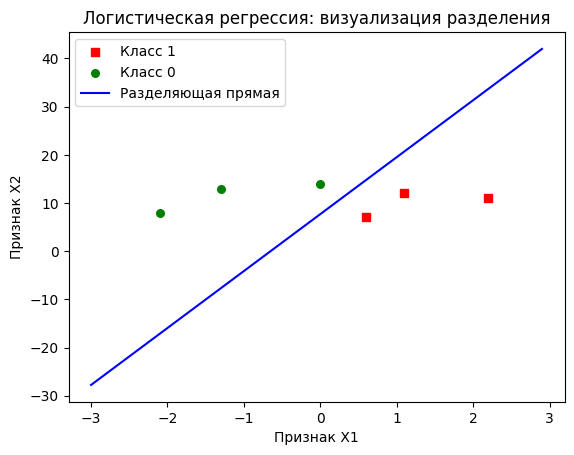

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random

def sigmoid(inX):
    """
    Сигмоидальная функция (активация).
    Масштабирует любое входное значение в диапазон от 0 до 1.
    Это позволяет интерпретировать результат как вероятность принадлежности к классу.
    """
    # np.clip предотвращает экстремально большие значения, которые вызывают ошибки расчетов
    return 1.0 / (1.0 + np.exp(-np.clip(inX, -100, 100)))

def gradAscent(dataMatIn, classLabels):
    """
    Классический градиентный восхождение (Batch Gradient Ascent).
    Оптимизирует веса, вычисляя ошибку сразу по всей выборке на каждой итерации.
    """
    # Подготовка данных в матричном виде для линейной алгебры
    dataMatrix = np.asmatrix(dataMatIn)
    labelMat = np.asmatrix(classLabels).transpose()
    m, n = np.shape(dataMatrix) # m - объектов, n - признаков

    alpha = 0.001       # Скорость обучения: как сильно мы меняем веса на каждом шаге
    maxCycles = 500     # Количество эпох (повторений) обучения
    weights = np.ones((n, 1)) # Инициализируем веса единицами

    for k in range(maxCycles):
        # 1. Вычисляем предсказание модели: z = X * W, затем применяем сигмоиду
        h = sigmoid(dataMatrix * weights)

        # 2. Вычисляем разницу между реальными метками и предсказанием (ошибку)
        error = (labelMat - h)

        # 3. Обновляем веса. Мы умножаем транспонированную матрицу признаков на вектор ошибок.
        # Это направление градиента, указывающее, как нужно изменить веса, чтобы уменьшить ошибку.
        weights = weights + alpha * dataMatrix.transpose() * error

    return weights

def stocGradAscent1(dataMatrix, classLabels, numIter=150):
    """
    Улучшенный стохастический градиентный спуск.
    В отличие от Batch-метода, обновляет веса после каждого отдельного примера.
    """
    dataMatrix = np.array(dataMatrix)
    m, n = np.shape(dataMatrix)
    weights = np.ones(n)

    for j in range(numIter):
        dataIndex = list(range(m))
        for i in range(m):
            # Адаптивный шаг обучения (alpha): уменьшается с каждой итерацией.
            # Это позволяет модели сначала делать большие шаги, а в конце — точные и мелкие.
            alpha = 4 / (1.0 + j + i) + 0.01

            # Случайный выбор объекта из выборки (shuffling).
            # Помогает избежать зацикливания и локальных минимумов.
            randIndex = int(random.uniform(0, len(dataIndex)))

            # Вычисляем предсказание только для одной выбранной точки
            h = sigmoid(np.sum(dataMatrix[randIndex] * weights))
            error = classLabels[randIndex] - h

            # Корректируем веса на основе ошибки в этой конкретной точке
            weights = weights + alpha * error * dataMatrix[randIndex]

            # Удаляем индекс, чтобы не использовать одну и ту же точку дважды за одну итерацию
            del(dataIndex[randIndex])

    return weights

def plotBestFit(weights, dataMat, labelMat):
    """
    Визуализация: строит диаграмму рассеяния и разделяющую прямую (Decision Boundary).
    """
    dataArr = np.array(dataMat)
    n = np.shape(dataArr)[0]
    xcord1 = []; ycord1 = []
    xcord2 = []; ycord2 = []

    # Распределяем точки по спискам в зависимости от их класса для окрашивания
    for i in range(n):
        if int(labelMat[i]) == 1:
            xcord1.append(dataArr[i, 1]); ycord1.append(dataArr[i, 2])
        else:
            xcord2.append(dataArr[i, 1]); ycord2.append(dataArr[i, 2])

    fig = plt.figure()
    ax = fig.add_subplot(111)
    ax.scatter(xcord1, ycord1, s=30, c='red', marker='s', label='Класс 1')
    ax.scatter(xcord2, ycord2, s=30, c='green', label='Класс 0')

    # Расчет прямой. Разделяющая граница находится там, где вероятность = 0.5 (т.е. z = 0).
    # Уравнение: w0*x0 + w1*x1 + w2*x2 = 0. Выразим x2 (вертикальная ось):
    # x2 = (-w0 - w1*x1) / w2
    x = np.arange(-3.0, 3.0, 0.1)

    # Превращаем веса в обычный массив для удобства расчетов
    if isinstance(weights, np.matrix):
        w = weights.getA().flatten()
    else:
        w = weights.flatten()

    y = (-w[0] - w[1] * x) / w[2]

    ax.plot(x, y, color='blue', label='Разделяющая прямая')
    plt.xlabel('Признак X1'); plt.ylabel('Признак X2')
    plt.legend()
    plt.title('Логистическая регрессия: визуализация разделения')
    plt.show()

def loadSimpleData():
    """
    Создает небольшой синтетический набор данных для проверки алгоритма.
    Первое число 1.0 — это x0 (фиктивный признак для смещения/intercept).
    """
    data = [[1.0, -0.01, 14.0], [1.0, -1.3, 13.0], [1.0, 2.2, 11.0],
            [1.0, 0.6, 7.0], [1.0, -2.1, 8.0], [1.0, 1.1, 12.0]]
    labels = [0, 0, 1, 1, 0, 1]
    return data, labels

if __name__ == "__main__":
    # Загружаем данные
    my_data, my_labels = loadSimpleData()

    print("Запуск обучения...")
    # Можно заменить на stocGradAscent1 для сравнения результатов
    ws = gradAscent(my_data, my_labels)

    print(f"Обучение завершено. Полученные веса:\n{ws}")

    # Строим график
    plotBestFit(ws, my_data, my_labels)

## Задания


### Задание №1. Batch Gradient Ascent

Реализуйте базовый алгоритм поиска оптимальных весов через матричные вычисления.

Для этого:

1. Напишите функцию, которая реализует логистическую функцию активации. Учтите возможность переполнения при работе с большими числами (используйте `np.clip`).
2. Реализуйте функцию, которая находит вектор весов $w$ для разделяющей гиперплоскости.
3. Внутри функции используйте матричное умножение для одновременного расчета предсказаний по всей выборке.
4. Формула обновления весов должна соответствовать градиенту функции правдоподобия:

$$w := w + \alpha X^T(y - \sigma(Xw))$$




### Задание №2. Оптимизация обучения (Stochastic Gradient Ascent)

1. Реализуйте функцию, в которой веса должны обновляться после анализа каждого отдельного объекта, а не всей матрицы сразу.
2. Внедрите **адаптивный шаг обучения (learning rate)**: сделайте коэффициент $\alpha$ зависимым от номера итерации, чтобы он уменьшался со временем. Это поможет избежать «проскакивания» оптимума.
3. Добавьте **случайный выбор объектов** на каждом шаге (shuffling), чтобы избежать циклов в данных и улучшить обобщающую способность модели.







---

### Задание №3: Визуализация границы решения (Decision Boundary)

1. Напишите функцию, которая строит диаграмму рассеяния (scatter plot) для двух признаков $X1$ и $X2$.
2. Используя полученный вектор весов $w = [w_0, w_1, w_2]$, постройте разделяющую прямую.
3. Отобразите прямую поверх точек данных и убедитесь, что она корректно разделяет два класса.


## Контрольные вопросы

1. Почему логистическая регрессия считается алгоритмом классификации, а не регрессии, несмотря на название?

2. Представьте, что один ваш признак — это возраст (от 0 до 100), а второй — годовой доход (в миллионах). Повлияет ли разница в масштабах на скорость сходимости градиентного спуска?

3. Существует ли риск для логистической регрессии «застрять» в плохом локальном минимуме, или ее функция потерь всегда имеет один глобальный оптимум?

4. Зачем мы добавляем фиктивный признак $x_0 = 1$ к каждому объекту в выборке? За что отвечает соответствующий ему вес $w_0$?




